# Offset vs magnitude, and whether catalog-rejected sources fill the branch gap

1. Redraw the offset vs F360M/F480M diagram with per-source offset error bars and a linear fit for each branch (no running medians).
2. Test whether the sources removed from the catalog fill the gap between the upper and lower branch in F162M−F210M vs F360M−F480M.

**How the current catalog was made** (`w51_catalog/notebooks/validity/mag_emag.ipynb`):
- start from `final_catalog_new.fits` (166,559 sources) and keep `nmatch_bands > 3` (31,560);
- remove a source entirely if |cfit| exceeds a per-band threshold in **any** band where it has flux (0.01 for F140M–F210M, 0.02 for F335M–F480M, 0.1 for MIRI);
- the result is `final_catalog_new_cfit_cut.fits` (15,004 sources).

Every source in the CCD has all four bands, so it already passes `nmatch_bands > 3`. The missing sources are therefore the cfit rejects. This notebook rebuilds the cut from the parent catalog and splits the rejects into two groups:
- **CCD-clean rejects:** pass the cfit threshold in all four CCD bands and were removed for fits in other bands, so their CCD photometry meets the same standard as the current catalog;
- **CCD-fail rejects:** exceed the threshold in at least one CCD band.

The boundary is the self-trained linear SVM from `branch_gap_svm_offset.ipynb`, fit on the current catalog only and then held fixed, so every sample is measured against the same line.

In [1]:
import os
FIGDIR = '/blue/adamginsburg/t.yoo/w51_nircam/analysis/plots_for_paper/figures/offset_vs_mag_faint_sources'
os.makedirs(FIGDIR, exist_ok=True)

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import CT06_MWLoc
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture
from scipy.stats import spearmanr

plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

CCD = ['f162m', 'f210m', 'f360m', 'f480m']
cfitcuts = {'f140m': 0.01, 'f162m': 0.01, 'f182m': 0.01, 'f187n': 0.01, 'f210m': 0.01, 'f335m': 0.02, 'f360m': 0.02,
            'f405n': 0.02, 'f410m': 0.02, 'f480m': 0.02, 'f560w': 0.1, 'f770w': 0.1, 'f1000w': 0.1, 'f1280w': 0.1,
            'f2100w': 0.1}

parent = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
parent = parent[parent['nmatch_bands'] > 3]

# rebuild the cfit cut of mag_emag.ipynb: reject a source if |cfit| > cut in any band with finite flux
rejected = np.zeros(len(parent), dtype=bool)
ccd_fail = np.zeros(len(parent), dtype=bool)
for f, c in cfitcuts.items():
    bad = np.isfinite(np.asarray(parent['flux_fit_' + f])) & (np.abs(np.asarray(parent['cfit_' + f])) > c)
    rejected |= bad
    if f in CCD:
        ccd_fail |= bad
current = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
assert (~rejected).sum() == len(current)
assert np.allclose(np.asarray(parent['flux_fit_f480m'])[~rejected], np.asarray(current['flux_fit_f480m']), equal_nan=True)
print(f'parent (nmatch_bands>3): {len(parent)}; kept by the cfit cut: {(~rejected).sum()} (matches the current catalog); '
      f'rejected: {rejected.sum()}')

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')
mag, emag = {}, {}
for f in CCD:
    zp = jfilts.loc[f'JWST/NIRCam.{f.upper()}']['ZeroPoint']
    fn = f'/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-{f}-merged_i2d.fits'
    pix = WCS(fits.getheader(fn, ext=('SCI', 1))).proj_plane_pixel_area().to_value(u.sr)
    flux = np.asarray(parent['flux_fit_' + f]) * 1e6 * pix   # MJy/sr -> Jy
    eflux = np.asarray(parent['flux_err_' + f]) * 1e6 * pix
    with np.errstate(invalid='ignore', divide='ignore'):
        mag[f] = -2.5 * np.log10(flux / zp)
        emag[f] = 2.5 / np.log(10) * np.abs(eflux / flux)
f162, f210, f360, f480 = (mag[f] for f in CCD)


parent (nmatch_bands>3): 31560; kept by the cfit cut: 15004 (matches the current catalog); rejected: 16556


In [2]:
# A_V: linear 1 Myr PARSEC isochrone in F162M-F210M vs F162M, CT06 MWLoc (color_magnitude_diagram_cleancat.ipynb)
parsec = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec = parsec[parsec['col4'] < 300]
dm = 5 * np.log10(5400) - 5
age_idx = parsec['col3'] == 6
iso_c = (parsec['col40'] - parsec['col42'])[age_idx]
iso_m = (parsec['col40'] + dm)[age_idx]
m_act = parsec['col6'][age_idx]
i01, i20 = np.argmin(np.abs(m_act - 0.1)), np.argmin(np.abs(m_act - 20))
m_iso = (iso_m[i20] - iso_m[i01]) / (iso_c[i20] - iso_c[i01])
b_iso = iso_m[i01] - m_iso * iso_c[i01]
ext = CT06_MWLoc()
A = {f: float(ext(1 / (int(f[1:-1]) / 100 * u.um))) for f in CCD}
m_ext = A['f162m'] / (A['f162m'] - A['f210m'])
x_int = ((f162 - m_ext * (f162 - f210)) - b_iso) / (m_iso - m_ext)
av_estimate = (f162 - (m_iso * x_int + b_iso)) / A['f162m']
av_estimate[av_estimate < 0] = 0

xcol, ycol = f162 - f210, f360 - f480
sample_all = np.isfinite(xcol) & np.isfinite(ycol) & (av_estimate > 12)
cur = sample_all & ~rejected                   # current catalog
add_clean = sample_all & rejected & ~ccd_fail  # rejected only for bands outside the CCD
add_fail = sample_all & rejected & ccd_fail    # rejected with a bad fit in a CCD band
print(f'A_V>12, 4-band sample: current {cur.sum()}, + CCD-clean rejects {add_clean.sum()}, '
      f'+ CCD-fail rejects {add_fail.sum()} (total {sample_all.sum()})')

# self-trained linear SVM on the current catalog (as in branch_gap_svm_offset.ipynb), then held fixed
X = np.column_stack([xcol[cur], ycol[cur]])
lab = (X[:, 1] > 0.15 + 0.25 * X[:, 0]).astype(int)
for _ in range(50):
    clf = SVC(kernel='linear', C=1, class_weight='balanced').fit(X, lab)
    new = clf.predict(X)
    if np.array_equal(new, lab):
        break
    lab = new
w, b0 = clf.coef_[0], clf.intercept_[0]
nw = np.hypot(*w)
sgn = np.sign(w[1])
svm_slope, svm_icpt = -w[0] / w[1], -b0 / w[1]
margin = 1 / nw
offset = sgn * (w[0] * xcol + w[1] * ycol + b0) / nw
# offset error: propagate the four magnitude errors through the (linear) perpendicular distance
offset_err = np.sqrt(w[0]**2 * (emag['f162m']**2 + emag['f210m']**2) + w[1]**2 * (emag['f360m']**2 + emag['f480m']**2)) / nw
print(f'boundary: F360M-F480M = {svm_icpt:.3f} + {svm_slope:.3f} (F162M-F210M); half-margin = {margin:.3f} mag')
for lbl, m in [('current', cur), ('CCD-clean rejects', add_clean), ('CCD-fail rejects', add_fail)]:
    print(f'  median offset error, {lbl}: {np.nanmedian(offset_err[m]):.3f} mag')


A_V>12, 4-band sample: current 3366, + CCD-clean rejects 1257, + CCD-fail rejects 836 (total 5459)
boundary: F360M-F480M = 0.124 + 0.242 (F162M-F210M); half-margin = 0.072 mag
  median offset error, current: 0.024 mag
  median offset error, CCD-clean rejects: 0.058 mag
  median offset error, CCD-fail rejects: 0.099 mag


## 1. Offset vs magnitude (current catalog), with error bars and linear fits

- **Error bars:** the offset uncertainty, propagated from the catalog `flux_err` of the four CCD bands.
- **Fits:** ordinary least squares of offset on magnitude for each branch. The 1σ uncertainties and shaded bands come from 1,000 bootstrap resamples.

The intrinsic scatter within each branch (~0.1 mag) is much larger than the typical offset error (~0.02 mag). An error-weighted fit would therefore be dominated by the brightest sources, so the fits are unweighted.

The branches are split at offset = 0, so each fit is truncated at the boundary. That truncation pulls both fitted lines toward zero where a branch's scatter reaches the boundary.

Dashed and dotted vertical lines mark the number-count turnover and the 95th percentile of detections, computed from all current-catalog detections in each band.

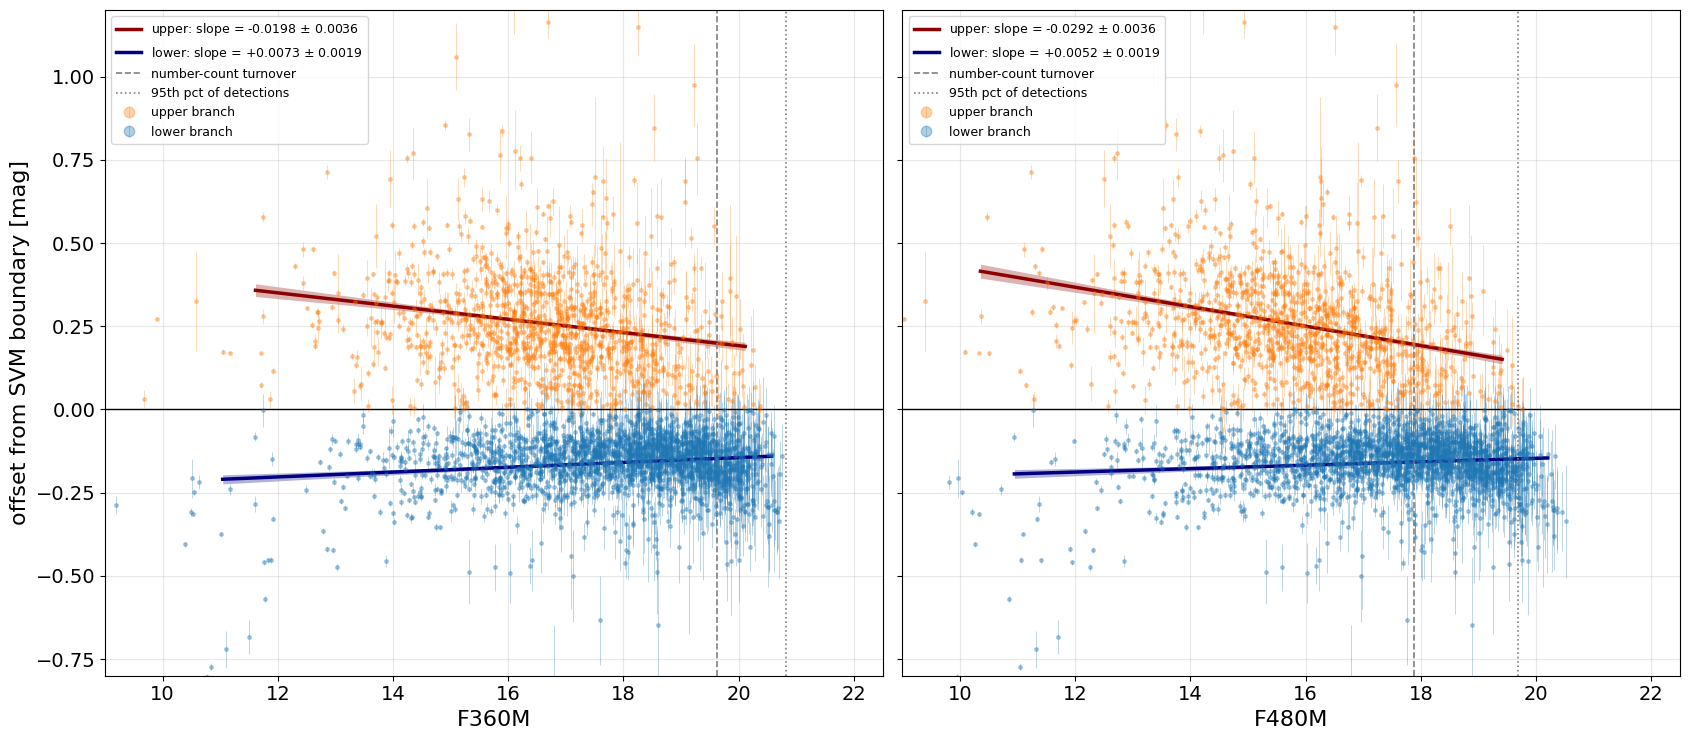

 band branch  N    slope  slope_err intercept intercept_err spearman_rho spearman_p
----- ------ ---- ------- --------- --------- ------------- ------------ ----------
F360M  upper 1168 -0.0198    0.0036    0.5882        0.0602      -0.2439    2.8e-17
F360M  lower 2198  0.0073    0.0019   -0.2901        0.0353       0.0103    6.3e-01
F480M  upper 1168 -0.0292    0.0036    0.7176        0.0585      -0.3324    1.6e-31
F480M  lower 2198  0.0052    0.0019   -0.2503        0.0340      -0.0296    1.7e-01


In [3]:
rng = np.random.default_rng(42)

def linfit_boot(xv, yv, nboot=1000):
    p = np.polyfit(xv, yv, 1)
    boots = np.empty((nboot, 2))
    for i in range(nboot):
        j = rng.integers(0, len(xv), len(xv))
        boots[i] = np.polyfit(xv[j], yv[j], 1)
    return p, boots

def plot_offset_vs_mag(masks, fname, title=None):
    """masks: list of (label, mask, color, marker) scatter groups; fits are done per branch on the union."""
    union = np.zeros_like(cur)
    for _, m, _, _ in masks:
        union |= m
    fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), sharey=True)
    rows = []
    for ax, f in zip(axes, ['f360m', 'f480m']):
        for lbl, m, c, mk in masks:
            ax.errorbar(mag[f][m], offset[m], yerr=offset_err[m], fmt=mk, ms=2.5, color=c, ecolor=c,
                        elinewidth=0.6, alpha=0.35, label=lbl)
        for br, bm, lc in [('upper', union & (offset > 0), 'darkred'), ('lower', union & (offset <= 0), 'navy')]:
            ok = bm & np.isfinite(mag[f])
            p, boots = linfit_boot(mag[f][ok], offset[ok])
            xx = np.linspace(np.nanpercentile(mag[f][ok], 0.5), np.nanpercentile(mag[f][ok], 99.5), 50)
            yb = boots[:, :1] * xx + boots[:, 1:]
            lo, hi = np.percentile(yb, [16, 84], axis=0)
            ax.fill_between(xx, lo, hi, color=lc, alpha=0.3, lw=0)
            ax.plot(xx, np.polyval(p, xx), color=lc, lw=2.5,
                    label=f'{br}: slope = {p[0]:+.4f} $\\pm$ {boots[:, 0].std():.4f}')
            r, pv = spearmanr(mag[f][ok], offset[ok])
            rows.append((f.upper(), br, ok.sum(), p[0], boots[:, 0].std(), p[1], boots[:, 1].std(), r, pv))
        ax.axvline(lims[f][0], color='gray', ls='--', lw=1.2, label='number-count turnover')
        ax.axvline(lims[f][1], color='gray', ls=':', lw=1.2, label='95th pct of detections')
        ax.axhline(0, color='k', lw=1)
        ax.set_xlabel(f.upper()); ax.set_xlim(9, 22.5); ax.set_ylim(-0.8, 1.2); ax.grid(alpha=0.3)
        ax.legend(fontsize=9, loc='upper left', markerscale=3)
    axes[0].set_ylabel('offset from SVM boundary [mag]')
    if title:
        fig.suptitle(title, fontsize=15)
    plt.tight_layout(); plt.savefig(f'{FIGDIR}/{fname}', bbox_inches='tight'); plt.show()
    t = Table(rows=rows, names=['band', 'branch', 'N', 'slope', 'slope_err', 'intercept', 'intercept_err', 'spearman_rho', 'spearman_p'],
              dtype=[str, str, int, float, float, float, float, float, float])
    for c in ['slope', 'slope_err', 'intercept', 'intercept_err', 'spearman_rho']:
        t[c].format = '.4f'
    t['spearman_p'].format = '.1e'
    return t

# detection-limit proxies from all current-catalog detections
lims = {}
for f in ['f360m', 'f480m']:
    mm = mag[f][~rejected & np.isfinite(mag[f])]
    h, e = np.histogram(mm, bins=np.arange(8, 30, 0.25))
    lims[f] = (e[np.argmax(h)] + 0.125, np.percentile(mm, 95))

fit_current = plot_offset_vs_mag([('upper branch', cur & (offset > 0), 'tab:orange', 'o'),
                                  ('lower branch', cur & (offset <= 0), 'tab:blue', 'o')],
                                 'offset_vs_mag_linfit_cfit003.png')
fit_current.pprint(max_width=-1)


## 2. Do the cfit-rejected sources fill the gap?

**Step 1: are the rejected sources fainter?** Compare their magnitudes and offset errors with the current sample's.

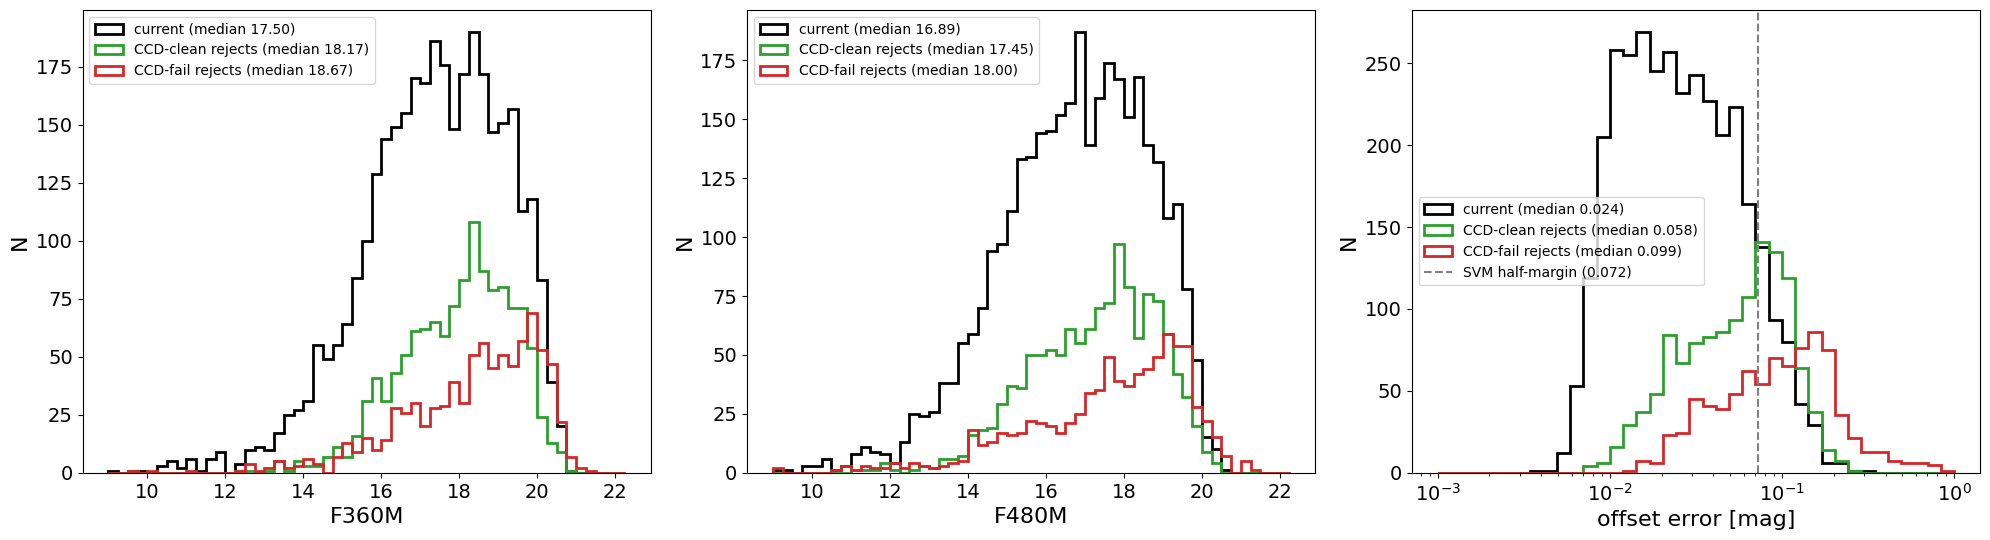

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, f in zip(axes[:2], ['f360m', 'f480m']):
    bins = np.arange(9, 22.5, 0.25)
    for lbl, m, c in [('current', cur, 'k'), ('CCD-clean rejects', add_clean, 'tab:green'), ('CCD-fail rejects', add_fail, 'tab:red')]:
        ax.hist(mag[f][m], bins=bins, histtype='step', lw=2, color=c, label=f'{lbl} (median {np.nanmedian(mag[f][m]):.2f})')
    ax.set_xlabel(f.upper()); ax.set_ylabel('N'); ax.legend(fontsize=10)
ax = axes[2]
bins = np.logspace(-3, 0, 40)
for lbl, m, c in [('current', cur, 'k'), ('CCD-clean rejects', add_clean, 'tab:green'), ('CCD-fail rejects', add_fail, 'tab:red')]:
    ax.hist(offset_err[m], bins=bins, histtype='step', lw=2, color=c, label=f'{lbl} (median {np.nanmedian(offset_err[m]):.3f})')
ax.axvline(margin, color='gray', ls='--', label=f'SVM half-margin ({margin:.3f})')
ax.set_xscale('log'); ax.set_xlabel('offset error [mag]'); ax.set_ylabel('N'); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/rejected_sources_mag_err_distributions.png', bbox_inches='tight'); plt.show()


**Step 2: where do the rejected sources fall?** The CCD and offset histograms with the rejected sources added. The boundary is the one fixed from the current catalog.

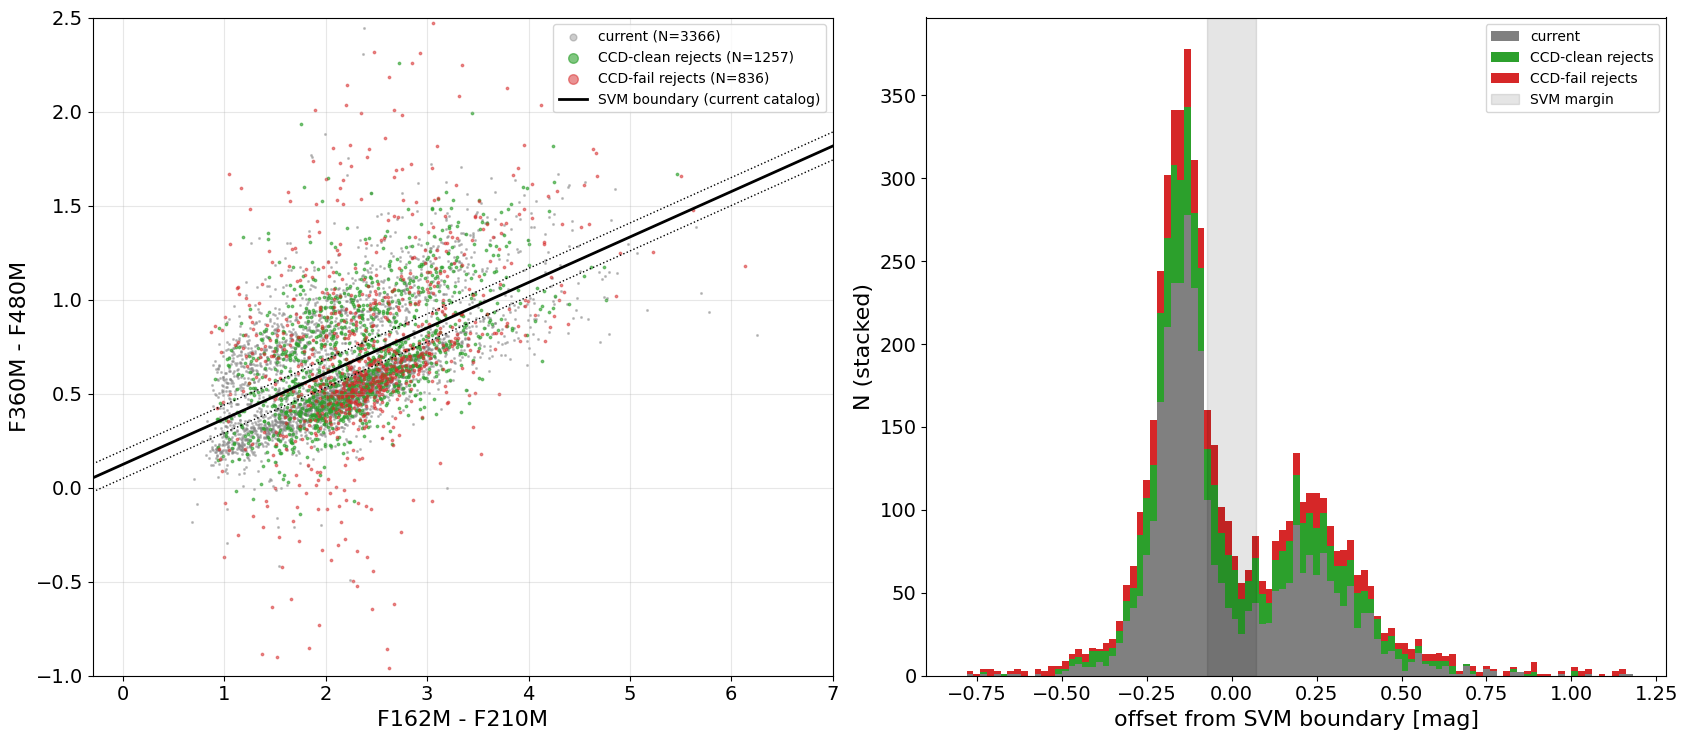

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
ax = axes[0]
ax.scatter(xcol[cur], ycol[cur], s=1.5, c='gray', alpha=0.4, label=f'current (N={cur.sum()})')
ax.scatter(xcol[add_clean], ycol[add_clean], s=3, c='tab:green', alpha=0.6, label=f'CCD-clean rejects (N={add_clean.sum()})')
ax.scatter(xcol[add_fail], ycol[add_fail], s=3, c='tab:red', alpha=0.5, label=f'CCD-fail rejects (N={add_fail.sum()})')
xx = np.linspace(-0.3, 7, 10)
ax.plot(xx, svm_icpt + svm_slope * xx, 'k-', lw=2, label='SVM boundary (current catalog)')
for s_ in [-1, 1]:
    ax.plot(xx, svm_icpt + svm_slope * xx + s_ * margin * np.hypot(1, svm_slope), 'k:', lw=1)
ax.set_xlim(-0.3, 7); ax.set_ylim(-1, 2.5)
ax.set_xlabel('F162M - F210M'); ax.set_ylabel('F360M - F480M'); ax.legend(fontsize=10, markerscale=4); ax.grid(alpha=0.3)

ax = axes[1]
bins = np.arange(-0.8, 1.2, 0.02)
ax.hist([offset[cur], offset[add_clean], offset[add_fail]], bins=bins, stacked=True,
        color=['gray', 'tab:green', 'tab:red'], label=['current', 'CCD-clean rejects', 'CCD-fail rejects'])
ax.axvspan(-margin, margin, color='k', alpha=0.1, label='SVM margin')
ax.set_xlabel('offset from SVM boundary [mag]'); ax.set_ylabel('N (stacked)'); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/ccd_rejected_sources_gap.png', bbox_inches='tight'); plt.show()


**Step 3: offset vs magnitude with all rejected sources included.** Same fitting as Section 1, applied to the current and rejected sources together.

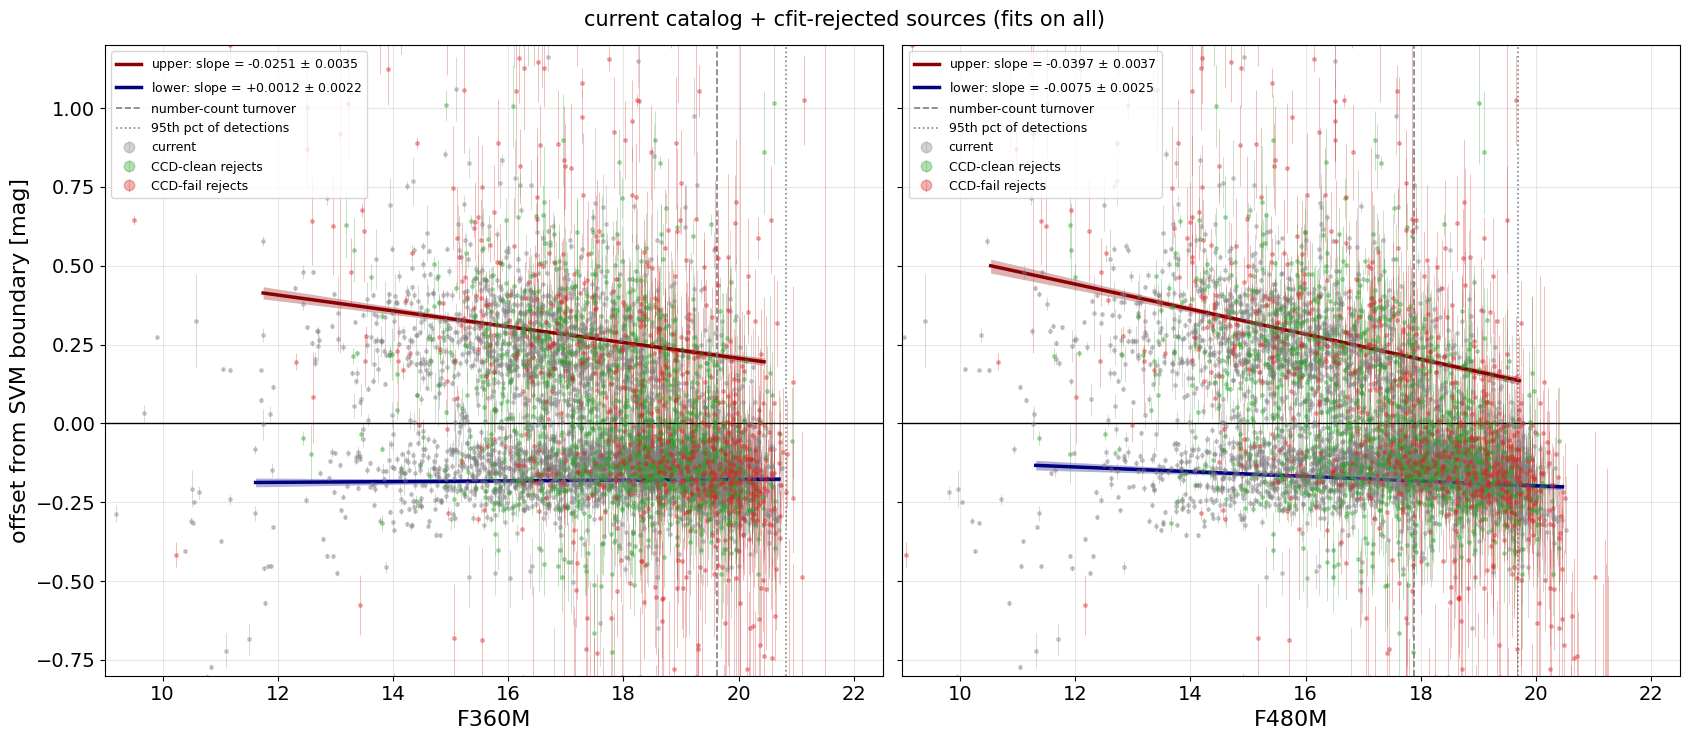

 band branch  N    slope  slope_err intercept intercept_err spearman_rho spearman_p
----- ------ ---- ------- --------- --------- ------------- ------------ ----------
F360M  upper 2044 -0.0251    0.0035    0.7082        0.0603      -0.2322    2.0e-26
F360M  lower 3415  0.0012    0.0022   -0.2009        0.0395      -0.0490    4.2e-03
F480M  upper 2044 -0.0397    0.0037    0.9182        0.0611      -0.3333    3.3e-54
F480M  lower 3415 -0.0075    0.0025   -0.0485        0.0440      -0.1121    5.0e-11


In [6]:
fit_all = plot_offset_vs_mag([('current', cur, 'gray', 'o'),
                              ('CCD-clean rejects', add_clean, 'tab:green', 'o'),
                              ('CCD-fail rejects', add_fail, 'tab:red', 'o')],
                             'offset_vs_mag_linfit_with_rejected.png',
                             title='current catalog + cfit-rejected sources (fits on all)')
fit_all.pprint(max_width=-1)


**Step 4: are the gap sources more than noise?** A source with a larger error scatters into the gap more often, even when the two branches are intrinsically separated. For each rejected source I:
1. draw a current-catalog source of similar F480M magnitude (one of its 60 nearest neighbors in F480M);
2. add Gaussian noise so the drawn source's offset error matches the rejected source's;
3. record whether the result falls in the gap (|offset| < half-margin).

Repeating this 300 times gives the gap fraction expected if the rejected sources follow the same two-branch distribution as current sources of the same brightness, blurred only by their larger errors. An observed fraction well above that expectation would indicate real intermediate-color sources.

In [7]:
idx_cur = np.where(cur)[0]
idx_cur = idx_cur[np.argsort(f480[idx_cur])]
cur_f480 = f480[idx_cur]

def gap_fraction_test(add, nsim=300, k=30):
    a = np.where(add)[0]
    pos = np.searchsorted(cur_f480, f480[a])
    no_noise, with_noise = [], []
    for _ in range(nsim):
        j = idx_cur[np.clip(pos + rng.integers(-k, k + 1, len(a)), 0, len(idx_cur) - 1)]
        extra = np.sqrt(np.clip(offset_err[a]**2 - offset_err[j]**2, 0, None))
        no_noise.append(np.mean(np.abs(offset[j]) < margin))
        with_noise.append(np.mean(np.abs(offset[j] + rng.normal(0, 1, len(a)) * extra) < margin))
    return len(a), np.mean(np.abs(offset[a]) < margin), np.mean(no_noise), np.mean(with_noise), np.std(with_noise)

rows = []
for lbl, add in [('CCD-clean rejects', add_clean), ('CCD-fail rejects', add_fail),
                 ('CCD-clean rejects, F480M<16.9', add_clean & (f480 < 16.9)),
                 ('CCD-fail rejects, F480M<16.9', add_fail & (f480 < 16.9))]:
    n, obs, nn, wn, wn_sd = gap_fraction_test(add)
    rows.append((lbl, n, obs, nn, wn, wn_sd, (obs - wn) / wn_sd))
t = Table(rows=rows, names=['group', 'N', 'observed gap frac', 'mag-matched current', 'mag-matched + noise',
                            'sim sigma', '(obs - sim)/sigma'], dtype=[str, int] + [float] * 5)
for c in t.colnames[2:]:
    t[c].format = '.3f'
print(f'current catalog gap fraction: {np.mean(np.abs(offset[cur]) < margin):.3f}')
t.pprint(max_width=-1)


current catalog gap fraction: 0.103
            group              N   observed gap frac mag-matched current mag-matched + noise sim sigma (obs - sim)/sigma
----------------------------- ---- ----------------- ------------------- ------------------- --------- -----------------
            CCD-clean rejects 1257             0.171               0.108               0.155     0.010             1.660
             CCD-fail rejects  836             0.133               0.103               0.156     0.012            -2.012
CCD-clean rejects, F480M<16.9  478             0.142               0.092               0.123     0.014             1.337
 CCD-fail rejects, F480M<16.9  253             0.055               0.080               0.135     0.021            -3.799


**Step 5: gap strength and gap deficit for each catalog version.**
- **Gap strength:** Ashman's D from a two-Gaussian fit to the offset, in the F480M quartiles of the current sample (D > 2 means two well-separated groups).
- **Deficit:** the number of sources needed to fill the gap up to a straight line between the two histogram peaks.

In [8]:
def ashman_d(dd):
    g = GaussianMixture(2, n_init=10, random_state=0).fit(dd.reshape(-1, 1))
    mu, sg = g.means_.ravel(), np.sqrt(g.covariances_.ravel())
    return abs(mu[0] - mu[1]) / np.sqrt((sg[0]**2 + sg[1]**2) / 2)

def deficit(dd):
    h, e = np.histogram(dd, bins=np.arange(-0.6, 0.8, 0.02))
    c = 0.5 * (e[1:] + e[:-1])
    il, iu = np.argmax(np.where(c < 0, h, -1)), np.argmax(np.where(c > 0, h, -1))
    bt = (c > c[il]) & (c < c[iu])
    return np.sum(np.interp(c[bt], [c[il], c[iu]], [h[il], h[iu]]) - h[bt]), h[bt].sum()

versions = [('current', cur), ('current + CCD-clean rejects', cur | add_clean), ('current + all rejects', sample_all)]
q = np.nanpercentile(f480[cur], [0, 25, 50, 75, 100]); q[-1] = 30
rows = []
for lbl, m in versions:
    dfc, inside = deficit(offset[m])
    row = [lbl, m.sum(), np.mean(offset[m] > 0), np.mean(np.abs(offset[m]) < margin), dfc, inside]
    for i in range(4):
        mm = m & (f480 >= q[i]) & (f480 < q[i + 1])
        row.append(ashman_d(offset[mm]))
    rows.append(tuple(row))
names = ['catalog', 'N', 'frac upper', 'gap frac', 'deficit', 'N between peaks'] + \
        [f'D F480M {q[i]:.1f}-{min(q[i+1], 21):.1f}' for i in range(4)]
t = Table(rows=rows, names=names, dtype=[str, int, float, float, float, int] + [float] * 4)
for c in names[2:]:
    if c != 'N between peaks':
        t[c].format = '.2f' if c != 'deficit' else '.0f'
t.pprint(max_width=-1)


          catalog            N   frac upper gap frac deficit N between peaks D F480M 8.1-15.5 D F480M 15.5-16.9 D F480M 16.9-18.2 D F480M 18.2-21.0
--------------------------- ---- ---------- -------- ------- --------------- ---------------- ----------------- ----------------- -----------------
                    current 3366       0.35     0.10    1704            1064             2.54              2.16              1.21              0.69
current + CCD-clean rejects 4623       0.37     0.12    1987            1493             1.90              2.88              1.10              0.86
      current + all rejects 5459       0.37     0.12    2118            1722             1.68              1.89              0.86              0.04


## Summary

The quantitative answers are in the tables above; they are restated here with the values from this run.

- **Linear fits (current catalog).** The upper-branch offset decreases toward fainter magnitudes: −0.020 ± 0.004 mag/mag in F360M and −0.029 ± 0.004 in F480M. The lower-branch slopes are small, +0.007 ± 0.002 and +0.005 ± 0.002 mag/mag, so both branches move slightly toward the boundary at faint magnitudes. Both fits are truncated at offset = 0 (Section 1).
- **How many sources are missing.** The cfit cut removes 16,556 of the 31,560 `nmatch_bands > 3` sources. In the A_V > 12, four-band CCD sample it removes 2,093 sources: 1,257 CCD-clean and 836 CCD-fail. Adding them increases the sample by 62%.
- **Who they are.** The rejected sources are fainter than the current sample (median F480M 17.5 and 18.0 vs 16.9) and have 2–4× larger offset errors. They fall in the upper branch at about the same rate as current sources (≈42% vs 35%).
- **Do they fill the gap?** Not beyond what their larger errors produce. The CCD-clean rejects lie in the gap slightly more often than noise alone predicts (≈1.6σ, roughly 20 sources); the CCD-fail rejects lie there less often. The deficit grows when rejects are added, because both branches gain more sources than the gap does.
- **Gap strength.** With all rejects added, Ashman's D drops in every F480M quartile: 2.54 → 1.68, 2.16 → 1.89, 1.21 → 0.86 and 0.69 → 0.04, from brightest to faintest. The noisier photometry widens both peaks. With only the CCD-clean rejects, D drops in the brightest quartile (1.90) but rises in the second (2.88).
- **Conclusion.** Restoring the cfit-rejected sources does not fill the gap. The gap is present among the bright, well-measured sources and remains in the extended sample.

**Caveat.** The noise test uses the catalog `flux_err`. If `flux_err` underestimates the error for poorly fit sources, the true blurring is larger, and the observed gap fractions would sit even closer to the noise expectation.